# SCG Hexane Extraction — Techno-Economic Analysis (TEA)
**BioSTEAM** simulation of Soxhlet extraction from spent coffee grounds (SCG) using **hexane** as solvent to recover the coffee oil (lipid) fraction, with full solvent recycle, TEA, sensitivity analysis, Monte Carlo uncertainty, and LCA.

| Parameter | Value |
|---|---|
| Feedstock | Wet SCG, 55% moisture |
| Solvent | Hexane (n-hexane) |
| Product | Coffee oil (lipid fraction) |
| Batch capacity | 1 000 kg wet SCG/batch |
| Batch time | 6 hr/batch → 1 200 batches/yr |
| Continuous equivalent | 166.67 kg/hr (300 d × 24 h = 7 200 hr/yr) |
| Solid:Liquid (S:L) ratio | 1:5 w/w |
| Extraction yield | 15.06% (dry SCG basis — coffee oil/lipids) |
| Solvent recovery | 99% (1% loss) |
| Hexane price | 1.141 USD/kg (1 141 USD/Mton) |
| Product price | 10.0 USD/kg (coffee oil) |
| Discount rate | 10% IRR |

**Flowsheet:**  
`U100 Dryer → U200 Soxhlet → U300 Filter → U400 Evaporator → U500 Distillation → U600 Mixer (recycle) → U700 Storage`


## 1. Thermodynamic property package
Define custom pseudo-components for the solid SCG matrix and the coffee oil extract (lipid proxy), then register hexane-based chemical system with BioSTEAM.


In [83]:
import biosteam as bst
from biosteam import Chemical
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

bst.nbtutorial()

# ── Spent coffee grounds solid matrix ────────────────────────────────────────
SCGSolids = Chemical(
    'SCGSolids',
    Cp=1.30, rho=650, default=True, search_db=False,
    phase='s', formula='C8H10O4', Hf=-975_708.8, MW=166.17,
)

# ── Coffee oil extract (lipid/triglyceride proxy) ────────────────────────────
CoffeeExtract = Chemical(
    'CoffeeExtract',
    Cp=1.80, rho=910, default=True, search_db=False,
    phase='l', formula='C57H110O6', Hf=-2_840_000, MW=891.48,
)

bst.settings.set_thermo(
    ['Water', 'Hexane', SCGSolids, CoffeeExtract],
    db='BioSTEAM',
)
print('✓ Thermo: Water | Hexane | SCGSolids | CoffeeExtract (coffee oil/lipid)')


✓ Thermo: Water | Hexane | SCGSolids | CoffeeExtract (coffee oil/lipid)


## 2. Process settings and basis
Set cost indices, utility prices, and all process parameters. Hexane-specific values (price, thermodynamic data) replace ethanol values; all other basis constants are identical to the ethanol case.


In [93]:
# ── Cost indices & utilities ──────────────────────────────────────────────────
bst.settings.CEPCI           = 800         # ≈ 2024
bst.settings.electricity_price = 0.1256   # USD/kWh

try:
    lps = bst.settings.get_agent('low_pressure_steam')
    lps.heat_transfer_efficiency = 0.90
except Exception:
    pass

# ── Prices & exchange ─────────────────────────────────────────────────────────
FX_THB        = 32.36
FX            = 1.0 / FX_THB
LANG_FACTOR   = 4.1

HEXANE_PRICE  = 1.141          # USD/kg  (1 141 USD/Mton)
PRODUCT_PRICE = 7.0           # USD/kg coffee oil

# ── Process basis ─────────────────────────────────────────────────────────────
# 1 000 kg/batch; 1 batch = 6 hr; 300 d × 24 h = 7 200 hr/yr → 1 200 batches/yr
OP_HOURS        = 7_200        # hr/yr
OP_DAYS         = 300          # days/yr
BATCH_SIZE_WET  = 1000.0       # kg wet SCG/batch
BATCH_TIME_HR   = 6.0          # hr/batch (Soxhlet cycle)
BATCHES_PER_YR  = OP_HOURS / BATCH_TIME_HR

FEED_RATE_WET   = BATCH_SIZE_WET / BATCH_TIME_HR   # kg/hr continuous equiv.
MOISTURE_IN     = 0.55         # 55% moisture
MOISTURE_OUT    = 0.05         # dry to 5%
SOLVENT_RATIO   = 5.0          # 1:5 w/w (dry SCG : hexane)
RECOVERY        = 0.99         # 99% solvent recovery
YIELD_FRAC      = 0.1506       # 15.06% coffee oil (dry SCG basis)

DRY_SCG_RATE    = FEED_RATE_WET * (1 - MOISTURE_IN)   # kg/hr dry solids
WATER_IN_RATE   = FEED_RATE_WET * MOISTURE_IN          # kg/hr water in feed
WATER_RETAINED  = DRY_SCG_RATE * MOISTURE_OUT / (1 - MOISTURE_OUT)
WATER_EVAP_DRYER = WATER_IN_RATE - WATER_RETAINED

SOLVENT_RATE    = SOLVENT_RATIO * DRY_SCG_RATE         # kg/hr total solvent needed
MAKEUP_RATE     = SOLVENT_RATE * (1 - RECOVERY)        # kg/hr fresh hexane

# Hexane thermodynamic constants (n-hexane, BP = 69 °C)
HEXANE_DATA = {'Hvap': 335.0, 'Cp': 2.27, 'BP': 342.15}  # kJ/kg, kJ/kg/K, K
WATER_DATA  = {'Hvap': 2257,  'Cp': 4.18, 'BP': 373.15}  # kJ/kg, kJ/kg/K, K

print(f'Batches/yr           : {BATCHES_PER_YR:.0f}')
print(f'Feed rate (wet SCG)  : {FEED_RATE_WET:.2f} kg/hr')
print(f'Dry SCG rate         : {DRY_SCG_RATE:.2f} kg/hr')
print(f'Water evap in dryer  : {WATER_EVAP_DRYER:.2f} kg/hr')
print(f'Solvent (hexane) needed: {SOLVENT_RATE:.2f} kg/hr')
print(f'Makeup hexane        : {MAKEUP_RATE:.3f} kg/hr')
print(f'Expected coffee oil  : {DRY_SCG_RATE * YIELD_FRAC:.3f} kg/hr')


Batches/yr           : 1200
Feed rate (wet SCG)  : 166.67 kg/hr
Dry SCG rate         : 75.00 kg/hr
Water evap in dryer  : 87.72 kg/hr
Solvent (hexane) needed: 375.00 kg/hr
Makeup hexane        : 3.750 kg/hr
Expected coffee oil  : 11.295 kg/hr


## 3. Custom unit operations
Each unit is implemented as a `bst.Unit` subclass with `_run()` (mass balance), `_design()` (energy/utility), and `_cost()` (purchased equipment cost + bare module factor).

| Unit | Description | Ins | Outs |
|---|---|---|---|
| U100 SCGDryer | Steam-heated dryer, 55% → 5% moisture | wet SCG | dry SCG + steam |
| U200 SoxhletExtractor | 1:5 S:L Soxhlet, reflux extraction | dry SCG + solvent | slurry |
| U300 VacuumFilter | Solid-liquid separation | slurry | filtrate + coffee cake |
| U400 ThinFilmEvaporator | Strip bulk hexane + water from extract | filtrate | dried extract + overhead vapor |
| U500 HexanePurifier | Shortcut distillation — hexane recovery (BP 69 °C) | vapor | purified hexane + wastewater |
| U600 Mixer | Blend recycled + makeup hexane | purified hexane + makeup | combined solvent |
| U700 StorageTank | Buffer product storage (24 hr) | dried extract | final product |


In [85]:
class SCGDryer(bst.Unit):
    """
    Steam-heated rotary/flash dryer.
    Reduces SCG moisture from 55% to moisture_out (default 5%).

    Ins  : [0] wet SCG (SCGSolids + Water)
    Outs : [0] dry SCG  | [1] steam / moisture vapor
    """
    _N_ins  = 1
    _N_outs = 2

    def __init__(self, ID='', ins=None, outs=(),
                 moisture_out=0.05, heater_eff=0.85,
                 purchase_cost_USD=12_000):
        super().__init__(ID, ins, outs)
        self.moisture_out   = moisture_out
        self.heater_eff     = heater_eff
        self._purchase_cost = purchase_cost_USD

    def _run(self):
        feed = self.ins[0]
        dry_scg, steam = self.outs

        m_solids = feed.imass['SCGSolids']
        m_water_in = feed.imass['Water']
        m_water_out = m_solids * self.moisture_out / (1.0 - self.moisture_out)
        m_water_evap = max(0.0, m_water_in - m_water_out)

        dry_scg.empty()
        dry_scg.imass['SCGSolids'] = m_solids
        dry_scg.imass['Water']     = m_water_out
        dry_scg.T     = 333.15   # 60 °C after drying
        dry_scg.phase = 'l'

        steam.empty()
        steam.imass['Water'] = m_water_evap
        steam.T     = WATER_DATA['BP']
        steam.phase = 'g'

    def _design(self):
        m_evap = self.outs[1].imass['Water']
        T_in   = 298.15
        Q_sen  = m_evap * WATER_DATA['Cp'] * (WATER_DATA['BP'] - T_in)
        Q_lat  = m_evap * WATER_DATA['Hvap']
        Q_tot  = (Q_sen + Q_lat) / self.heater_eff
        self.add_heat_utility(Q_tot, T_in=T_in, T_out=WATER_DATA['BP'])
        self.add_power_utility(1.5)   # rotary drum motor

    def _cost(self):
        self.baseline_purchase_costs['SCG dryer'] = self._purchase_cost
        self.F_BM['SCG dryer'] = LANG_FACTOR


class SoxhletExtractor(bst.Unit):
    """
    Soxhlet solid-liquid extractor, 1:5 S:L ratio, hexane solvent.

    Ins  : [0] dry SCG  | [1] solvent (Hexane)
    Outs : [0] mixed slurry (Hexane + CoffeeExtract + SCGSolids + Water)
    """
    _N_ins  = 2
    _N_outs = 1

    def __init__(self, ID='', ins=None, outs=(),
                 yield_frac=YIELD_FRAC, reflux_cycles=3, vap_frac_cycle=0.05,
                 heater_eff=0.90, purchase_cost_USD=20_000):
        super().__init__(ID, ins, outs)
        self.yield_frac      = yield_frac
        self.reflux_cycles   = reflux_cycles
        self.vap_frac_cycle  = vap_frac_cycle
        self.heater_eff      = heater_eff
        self._purchase_cost  = purchase_cost_USD

    def _run(self):
        feed, solvent = self.ins
        slurry = self.outs[0]
        m_solids  = feed.imass['SCGSolids']
        extracted = m_solids * self.yield_frac

        slurry.empty()
        slurry.imass['Hexane']        = solvent.imass['Hexane']
        slurry.imass['CoffeeExtract'] = extracted
        slurry.imass['SCGSolids']     = m_solids - extracted
        slurry.imass['Water']         = feed.imass['Water']
        slurry.T     = HEXANE_DATA['BP']
        slurry.phase = 'l'

    def _design(self):
        m_solvent = self.ins[1].imass['Hexane']
        T_in      = 298.15
        Q_heatup  = m_solvent * HEXANE_DATA['Cp'] * (HEXANE_DATA['BP'] - T_in)
        m_reflux  = self.reflux_cycles * self.vap_frac_cycle * m_solvent
        Q_reflux  = m_reflux * HEXANE_DATA['Hvap']
        Q_tot     = (Q_heatup + Q_reflux) / self.heater_eff
        self.add_heat_utility(Q_tot, T_in=T_in, T_out=HEXANE_DATA['BP'])
        self.add_heat_utility(-Q_reflux, T_in=318.15, T_out=305.15)  # condenser
        self.add_power_utility(0.75)

    def _cost(self):
        self.baseline_purchase_costs['Soxhlet extractor'] = self._purchase_cost
        self.F_BM['Soxhlet extractor'] = LANG_FACTOR


class VacuumFilter(bst.Unit):
    """
    Vacuum filter: separates clarified filtrate from spent coffee cake.

    Ins  : [0] slurry
    Outs : [0] filtrate (Hexane + CoffeeExtract + Water)
           [1] coffee cake (SCGSolids + residual water)
    """
    _N_ins  = 1
    _N_outs = 2

    def __init__(self, ID='', ins=None, outs=(),
                 liquid_recovery=1.0, purchase_cost_USD=4_500):
        super().__init__(ID, ins, outs)
        self.liquid_recovery = liquid_recovery
        self._purchase_cost  = purchase_cost_USD

    def _run(self):
        feed = self.ins[0]
        filtrate, cake = self.outs

        filtrate.empty()
        filtrate.imass['Hexane']        = feed.imass['Hexane']        * self.liquid_recovery
        filtrate.imass['CoffeeExtract'] = feed.imass['CoffeeExtract'] * self.liquid_recovery
        filtrate.imass['Water']         = feed.imass['Water']         * self.liquid_recovery
        filtrate.T     = feed.T
        filtrate.phase = 'l'

        cake.empty()
        cake.imass['SCGSolids'] = feed.imass['SCGSolids']
        cake.imass['Water']     = feed.imass['Water'] * (1 - self.liquid_recovery)
        cake.T = feed.T

    def _design(self):
        self.add_power_utility(0.37)

    def _cost(self):
        self.baseline_purchase_costs['Vacuum filter'] = self._purchase_cost
        self.F_BM['Vacuum filter'] = LANG_FACTOR


class ThinFilmEvaporator(bst.Unit):
    """
    Thin-film evaporator: strips bulk hexane + water from coffee oil extract.
    Hexane BP (69 °C) is below water BP — gentle vacuum not required.

    Ins  : [0] filtrate (Hexane + CoffeeExtract + Water)
    Outs : [0] dried product (CoffeeExtract + trace water)
           [1] overhead vapor (Hexane + Water → sent to distillation)
    """
    _N_ins  = 1
    _N_outs = 2

    def __init__(self, ID='', ins=None, outs=(),
                 hexane_removal=0.995, water_removal=0.80,
                 T_evap=353.15, heater_eff=0.90, purchase_cost_USD=8_000):
        super().__init__(ID, ins, outs)
        self.hexane_removal  = hexane_removal
        self.water_removal   = water_removal
        self.T_evap          = T_evap
        self.heater_eff      = heater_eff
        self._purchase_cost  = purchase_cost_USD

    def _run(self):
        feed = self.ins[0]
        product, vapor = self.outs

        m_hexane  = feed.imass['Hexane']
        m_water   = feed.imass['Water']
        m_extract = feed.imass['CoffeeExtract']

        hexane_evap = m_hexane * self.hexane_removal
        water_evap  = m_water  * self.water_removal

        product.empty()
        product.imass['CoffeeExtract'] = m_extract
        product.imass['Hexane']        = m_hexane - hexane_evap
        product.imass['Water']         = m_water  - water_evap
        product.T     = self.T_evap
        product.phase = 'l'

        vapor.empty()
        vapor.imass['Hexane'] = hexane_evap
        vapor.imass['Water']  = water_evap
        vapor.T     = self.T_evap
        vapor.phase = 'g'

    def _design(self):
        vapor = self.outs[1]
        T_in  = 298.15
        m_hex = vapor.imass['Hexane']
        m_wat = vapor.imass['Water']
        Q  = (m_hex * HEXANE_DATA['Cp'] + m_wat * WATER_DATA['Cp']) * (self.T_evap - T_in)
        Q += m_hex * HEXANE_DATA['Hvap'] + m_wat * WATER_DATA['Hvap']
        Q /= self.heater_eff
        self.add_heat_utility(Q, T_in=T_in, T_out=self.T_evap)
        self.add_heat_utility(-(m_hex * HEXANE_DATA['Hvap'] + m_wat * WATER_DATA['Hvap']),
                              T_in=318.15, T_out=305.15)
        self.add_power_utility(0.75)

    def _cost(self):
        self.baseline_purchase_costs['Thin-film evaporator'] = self._purchase_cost
        self.F_BM['Thin-film evaporator'] = LANG_FACTOR


class HexanePurifier(bst.Unit):
    """
    Shortcut distillation: separates hexane (BP 69 °C) from water (BP 100 °C).
    Hexane goes overhead; water leaves as bottoms. No VLE solver needed.

    Ins  : [0] vapor feed (Hexane + Water)
    Outs : [0] purified hexane (top)  ← recycled to U600
           [1] wastewater (bottom)
    """
    _N_ins  = 1
    _N_outs = 2

    def __init__(self, ID='', ins=None, outs=(),
                 hexane_recovery=0.98, hexane_purity=0.95,
                 heater_eff=0.85, purchase_cost_USD=15_000):
        super().__init__(ID, ins, outs)
        self.hexane_recovery = hexane_recovery
        self.hexane_purity   = hexane_purity
        self.heater_eff      = heater_eff
        self._purchase_cost  = purchase_cost_USD

    def _run(self):
        feed = self.ins[0]
        top, bottoms = self.outs

        m_hex_in  = feed.imass['Hexane']
        m_hex_top = m_hex_in * self.hexane_recovery
        # water co-distilled to meet purity target
        m_wat_top = m_hex_top * (1 - self.hexane_purity) / self.hexane_purity

        top.empty()
        top.imass['Hexane'] = m_hex_top
        top.imass['Water']  = m_wat_top
        top.T     = HEXANE_DATA['BP']
        top.phase = 'l'

        bottoms.empty()
        bottoms.imass['Water']  = feed.imass['Water'] - m_wat_top
        bottoms.imass['Hexane'] = m_hex_in * (1 - self.hexane_recovery)
        bottoms.T     = WATER_DATA['BP']
        bottoms.phase = 'l'

    def _design(self):
        feed = self.ins[0]
        m_tot = feed.F_mass
        T_in = HEXANE_DATA['BP']  # vapor already at BP from U400
        Q_reb = m_tot * HEXANE_DATA['Cp'] * 20    # ~20 K superheat
        Q_reb += self.outs[0].imass['Hexane'] * HEXANE_DATA['Hvap'] * 0.5  # partial
        Q_reb /= self.heater_eff
        self.add_heat_utility(Q_reb, T_in=T_in, T_out=T_in + 20)
        self.add_heat_utility(-Q_reb * 0.8, T_in=318.15, T_out=305.15)  # condenser
        self.add_power_utility(0.55)

    def _cost(self):
        self.baseline_purchase_costs['Distillation column'] = self._purchase_cost
        self.F_BM['Distillation column'] = LANG_FACTOR


print('✓ Units defined: SCGDryer | SoxhletExtractor | VacuumFilter | ThinFilmEvaporator | HexanePurifier')


✓ Units defined: SCGDryer | SoxhletExtractor | VacuumFilter | ThinFilmEvaporator | HexanePurifier


## 4. System build and simulation
Wire up streams and units into a closed-loop flowsheet with hexane recycle, then simulate to steady state. A makeup specification keeps total hexane flow at the 1:5 S:L target.


In [86]:
bst.main_flowsheet.set_flowsheet('scg_hexane_v1')

# ── Feed and solvent streams ──────────────────────────────────────────────────
scg_feed = bst.Stream(
    'scg_feed',
    SCGSolids = DRY_SCG_RATE,
    Water     = WATER_IN_RATE,
    units='kg/hr', price=0.0,
)

makeup_hexane = bst.Stream(
    'makeup_hexane',
    Hexane = MAKEUP_RATE,
    units='kg/hr', price=HEXANE_PRICE,
)

recycled_hexane = bst.Stream('recycled_hexane')

# ── Unit operations ───────────────────────────────────────────────────────────
U100 = SCGDryer('U100', ins=scg_feed, outs=['dry_scg', 'dryer_steam'],
                moisture_out=MOISTURE_OUT)

U600 = bst.units.Mixer('U600', ins=[makeup_hexane, recycled_hexane],
                        outs='combined_solvent')

U200 = SoxhletExtractor('U200', ins=[U100-0, U600-0], outs=['slurry'],
                         yield_frac=YIELD_FRAC)

U300 = VacuumFilter('U300', ins=U200-0, outs=['filtrate', 'coffee_cake'])

U400 = ThinFilmEvaporator('U400', ins=U300-0,
                           outs=['dried_extract', 'overhead_vapor'],
                           hexane_removal=0.995, water_removal=0.80)

U500 = HexanePurifier('U500', ins=U400-1,
                       outs=[recycled_hexane, 'wastewater'],
                       hexane_recovery=0.98, hexane_purity=0.95)

# Product storage
U700 = bst.units.StorageTank('U700', ins=U400-0, outs='product',
                              tau=24, vessel_material='Stainless steel')

product_stream = U700.outs[0]

# ── Price only the CoffeeExtract fraction of the product stream ───────────────
# _current_selling_price stores the latest selling price (may be changed during sensitivity sweeps)
# update_product_price() always uses this cached value → metrics stay consistent after coupled changes
_current_selling_price = PRODUCT_PRICE

def update_product_price(selling_price=None):
    """
    Set product_stream.price so that revenue accounts for CoffeeExtract mass fraction only.
    If selling_price is provided, it is cached as the latest price.
    If omitted, the cached price is reused (e.g., after a coupled parameter changes composition).
    """
    global _current_selling_price
    if selling_price is not None:
        _current_selling_price = selling_price
    total = product_stream.F_mass
    if total > 0:
        extract_frac = product_stream.imass['CoffeeExtract'] / total
        product_stream.price = _current_selling_price * extract_frac

# ── Makeup specification: maintain target solvent flow ────────────────────────
@U600.add_specification(run=True)
def makeup_spec():
    recycled = recycled_hexane.imass['Hexane']
    makeup_hexane.imass['Hexane'] = max(0.0, SOLVENT_RATE - recycled)
    U600._run()

# ── Build and simulate ────────────────────────────────────────────────────────
sys = bst.main_flowsheet.create_system('scg_hex_sys')
sys.simulate()
update_product_price()   # apply CoffeeExtract-only pricing after first simulation

# ── Stream summary ────────────────────────────────────────────────────────────
extract_rate  = product_stream.imass['CoffeeExtract']
recycled_rate = recycled_hexane.imass['Hexane']
makeup_actual = makeup_hexane.imass['Hexane']

print('✓ System converged\n')
print(f'{"─"*60}')
print(f'  Stream Summary')
print(f'{"─"*60}')
print(f'  Wet SCG feed             : {scg_feed.F_mass:>8.2f}  kg/hr')
print(f'  Dryer steam out          : {U100.outs[1].imass["Water"]:>8.2f}  kg/hr')
print(f'  Dry SCG to extractor     : {U100.outs[0].F_mass:>8.2f}  kg/hr')
print(f'  Solvent to extractor     : {U600.outs[0].imass["Hexane"]:>8.2f}  kg/hr')
print(f'  Recycled hexane (U500)   : {recycled_rate:>8.2f}  kg/hr')
print(f'  Makeup hexane            : {makeup_actual:>8.3f}  kg/hr')
print(f'  Filtrate to evaporator   : {U300.outs[0].F_mass:>8.2f}  kg/hr')
print(f'  Coffee cake (discarded)  : {U300.outs[1].F_mass:>8.2f}  kg/hr')
print(f'  Overhead vapor to still  : {U400.outs[1].F_mass:>8.2f}  kg/hr')
print(f'  Product (CoffeeExtract)  : {extract_rate:>8.3f}  kg/hr')
print(f'  Wastewater (U500 btm)    : {U500.outs[1].F_mass:>8.2f}  kg/hr')
print(f'{"─"*60}')
print(f'  Annual coffee oil prod.  : {extract_rate * OP_HOURS / 1000:>8.2f}  t/yr')
print(f'{"─"*60}')
print(f'  Effective stream price   : {product_stream.price:.4f}  USD/kg'
      f'  (= {_current_selling_price} × {extract_rate / product_stream.F_mass:.4f})')
print(f'  → Revenue = CoffeeExtract only ✓')

sys.diagram()


✓ System converged

────────────────────────────────────────────────────────────
  Stream Summary
────────────────────────────────────────────────────────────
  Wet SCG feed             :   166.67  kg/hr
  Dryer steam out          :    87.72  kg/hr
  Dry SCG to extractor     :    78.95  kg/hr
  Solvent to extractor     :   375.00  kg/hr
  Recycled hexane (U500)   :   365.66  kg/hr
  Makeup hexane            :    9.337  kg/hr
  Filtrate to evaporator   :   390.24  kg/hr
  Coffee cake (discarded)  :    63.70  kg/hr
  Overhead vapor to still  :   376.28  kg/hr
  Product (CoffeeExtract)  :   11.295  kg/hr
  Wastewater (U500 btm)    :    -8.63  kg/hr
────────────────────────────────────────────────────────────
  Annual coffee oil prod.  :    81.32  t/yr
────────────────────────────────────────────────────────────
  Effective stream price   : 4.8548  USD/kg  (= 6.0 × 0.8091)
  → Revenue = CoffeeExtract only ✓


## 5. Unit group analysis
Break down installed equipment cost, heating/cooling duties, electricity, and material costs by process area to identify cost drivers.


In [87]:
UnitGroup = bst.process_tools.UnitGroup
unit_groups = UnitGroup.group_by_area(sys.units)
for group in unit_groups:
    group.autofill_metrics(shorthand=True)

area_map = {
    '100': 'U100 Dryer',
    '200': 'U200 Soxhlet',
    '300': 'U300 Filter',
    '400': 'U400 Evaporator',
    '500': 'U500 HexanePurif.',
    '600': 'U600 Mixer/Recycle',
    '700': 'U700 Storage',
}
for g in unit_groups:
    g.name = area_map.get(g.name, g.name)

df_ug = UnitGroup.df_from_groups(unit_groups)
print(df_ug.to_string())

                    Inst. eq. cost [MM$]  Cooling [GJ/hr]  Heating [GJ/hr]  Elec. cons. [MW]  Mat. cost [USD/hr]
U100 Dryer                        0.0492                0            0.295            0.0015                   0
U200 Soxhlet                       0.082           0.0188           0.0695           0.00075                   0
U300 Filter                       0.0185                0                0           0.00037                   0
U400 Evaporator                   0.0328            0.132            0.222           0.00075                   0
U500 HexanePurif.                 0.0615           0.0737            0.102           0.00055                   0
U600 Mixer/Recycle                     0                0                0                 0                10.7
U700 Storage                       0.163                0                0                 0                   0


## 6. Techno-Economic Analysis (TEA)
Compute TCI, FCI, OPEX, revenue, NPV, IRR, payback period, ROI, and MPSP using a 10-year straight-line depreciation model at 10% discount rate.


In [88]:
class SimpleTEA(bst.TEA):
    def _DPI(self, installed_equipment_cost): return installed_equipment_cost
    def _TDC(self, DPI):                      return DPI
    def _FCI(self, TDC):                      return TDC
    def _FOC(self, FCI):                      return 0.10 * FCI

tea = SimpleTEA(
    system                = sys,
    IRR                   = 0.10,
    duration              = (2025, 2035),
    depreciation          = 'SL10',
    income_tax            = 0.20,
    operating_days        = OP_DAYS,
    lang_factor           = None,
    construction_schedule = (1.0,),
    startup_months        = 3,
    startup_FOCfrac       = 1.0,
    startup_VOCfrac       = 0.25,
    startup_salesfrac     = 0.50,
    WC_over_FCI           = 0.15,
    finance_interest      = 0.0,
    finance_years         = 0,
    finance_fraction      = 0,
)

update_product_price()   # ← ensure CoffeeExtract-only pricing before TEA

irr       = tea.solve_IRR()
npv       = tea.NPV
mpsp_raw  = tea.solve_price(product_stream)   # effective price per kg stream
# convert MPSP back to "per kg CoffeeExtract"
mpsp = mpsp_raw / (product_stream.imass['CoffeeExtract'] / product_stream.F_mass)
annual_NI = tea.net_earnings
dep       = tea.FCI / 10.0
payback   = (tea.TCI / (annual_NI + dep)
             if (annual_NI + dep) > 0 else float('inf'))
roi       = annual_NI / tea.TCI if tea.TCI > 0 else 0.0

update_product_price()   # restore after solve_price

print(f'\n{"="*60}')
print(f'  Techno-Economic Analysis — SCG Hexane Extraction (v1)')
print(f'  Basis: 1 000 kg/batch · 300 d/yr · 7 200 hr/yr')
print(f'{"="*60}')
print(f'  TCI                  : {tea.TCI:>12,.0f}  USD   ({tea.TCI * FX_THB / 1e6:.2f} M THB)')
print(f'  FCI                  : {tea.FCI:>12,.0f}  USD   ({tea.FCI * FX_THB / 1e6:.2f} M THB)')
print(f'  Annual OPEX (VOC)    : {tea.VOC:>12,.0f}  USD/yr')
print(f'  Annual FOC           : {tea.FOC:>12,.0f}  USD/yr')
print(f'  Annual Revenue       : {tea.sales:>12,.0f}  USD/yr  (CoffeeExtract only)')
print(f'  Net income / yr      : {annual_NI:>12,.0f}  USD/yr')
print(f'  NPV (10 yr, 10%)     : {npv:>12,.0f}  USD   ({npv * FX_THB / 1e6:.2f} M THB)')
print(f'  IRR                  : {irr * 100:>11.1f}  %')
print(f'  Payback period       : {payback:>11.2f}  yr')
print(f'  ROI                  : {roi * 100:>11.1f}  %')
print(f'  MPSP (per kg extract): {mpsp:>11.2f}  USD/kg  ({mpsp * FX_THB:.0f} THB/kg)')
print(f'{"="*60}')


  Techno-Economic Analysis — SCG Hexane Extraction (v1)
  Basis: 1 000 kg/batch · 300 d/yr · 7 200 hr/yr
  TCI                  :      468,522  USD   (15.16 M THB)
  FCI                  :      407,410  USD   (13.18 M THB)
  Annual OPEX (VOC)    :      118,804  USD/yr
  Annual FOC           :       40,741  USD/yr
  Annual Revenue       :      487,944  USD/yr  (CoffeeExtract only)
  Net income / yr      :      262,719  USD/yr
  NPV (10 yr, 10%)     :    1,191,245  USD   (38.55 M THB)
  IRR                  :        54.8  %
  Payback period       :        1.54  yr
  ROI                  :        56.1  %
  MPSP (per kg extract):        2.96  USD/kg  (96 THB/kg)


## 7. Sensitivity Analysis
Single-point (one-at-a-time) sensitivity sweep over five key parameters to rank their influence on IRR, NPV, and MPSP, visualised as a tornado chart.



  Single-Point Sensitivity Analysis  (5 parameters)

  IRR metric [%]  baseline = 65.6
    Yld pct                       : [     33.8  …       95.1]  swing=61.3
    Pct                           : [     60.9  …         68]  swing=7.06
    Price                         : [     38.8  …        104]  swing=65.3
    Price                         : [     69.9  …       61.1]  swing=8.81
    Days                          : [     53.8  …       72.6]  swing=18.9

  NPV metric [M USD]  baseline = 1.51
    Yld pct                       : [    0.589  …       2.41]  swing=1.82
    Pct                           : [     1.37  …       1.58]  swing=0.215
    Price                         : [    0.727  …       2.69]  swing=1.96
    Price                         : [     1.64  …       1.37]  swing=0.269
    Days                          : [     1.16  …       1.72]  swing=0.562

  MPSP metric [USD/kg]  baseline = 3.15
    Yld pct                       : [     4.74  …       2.37]  swing=2.37
    Pct        

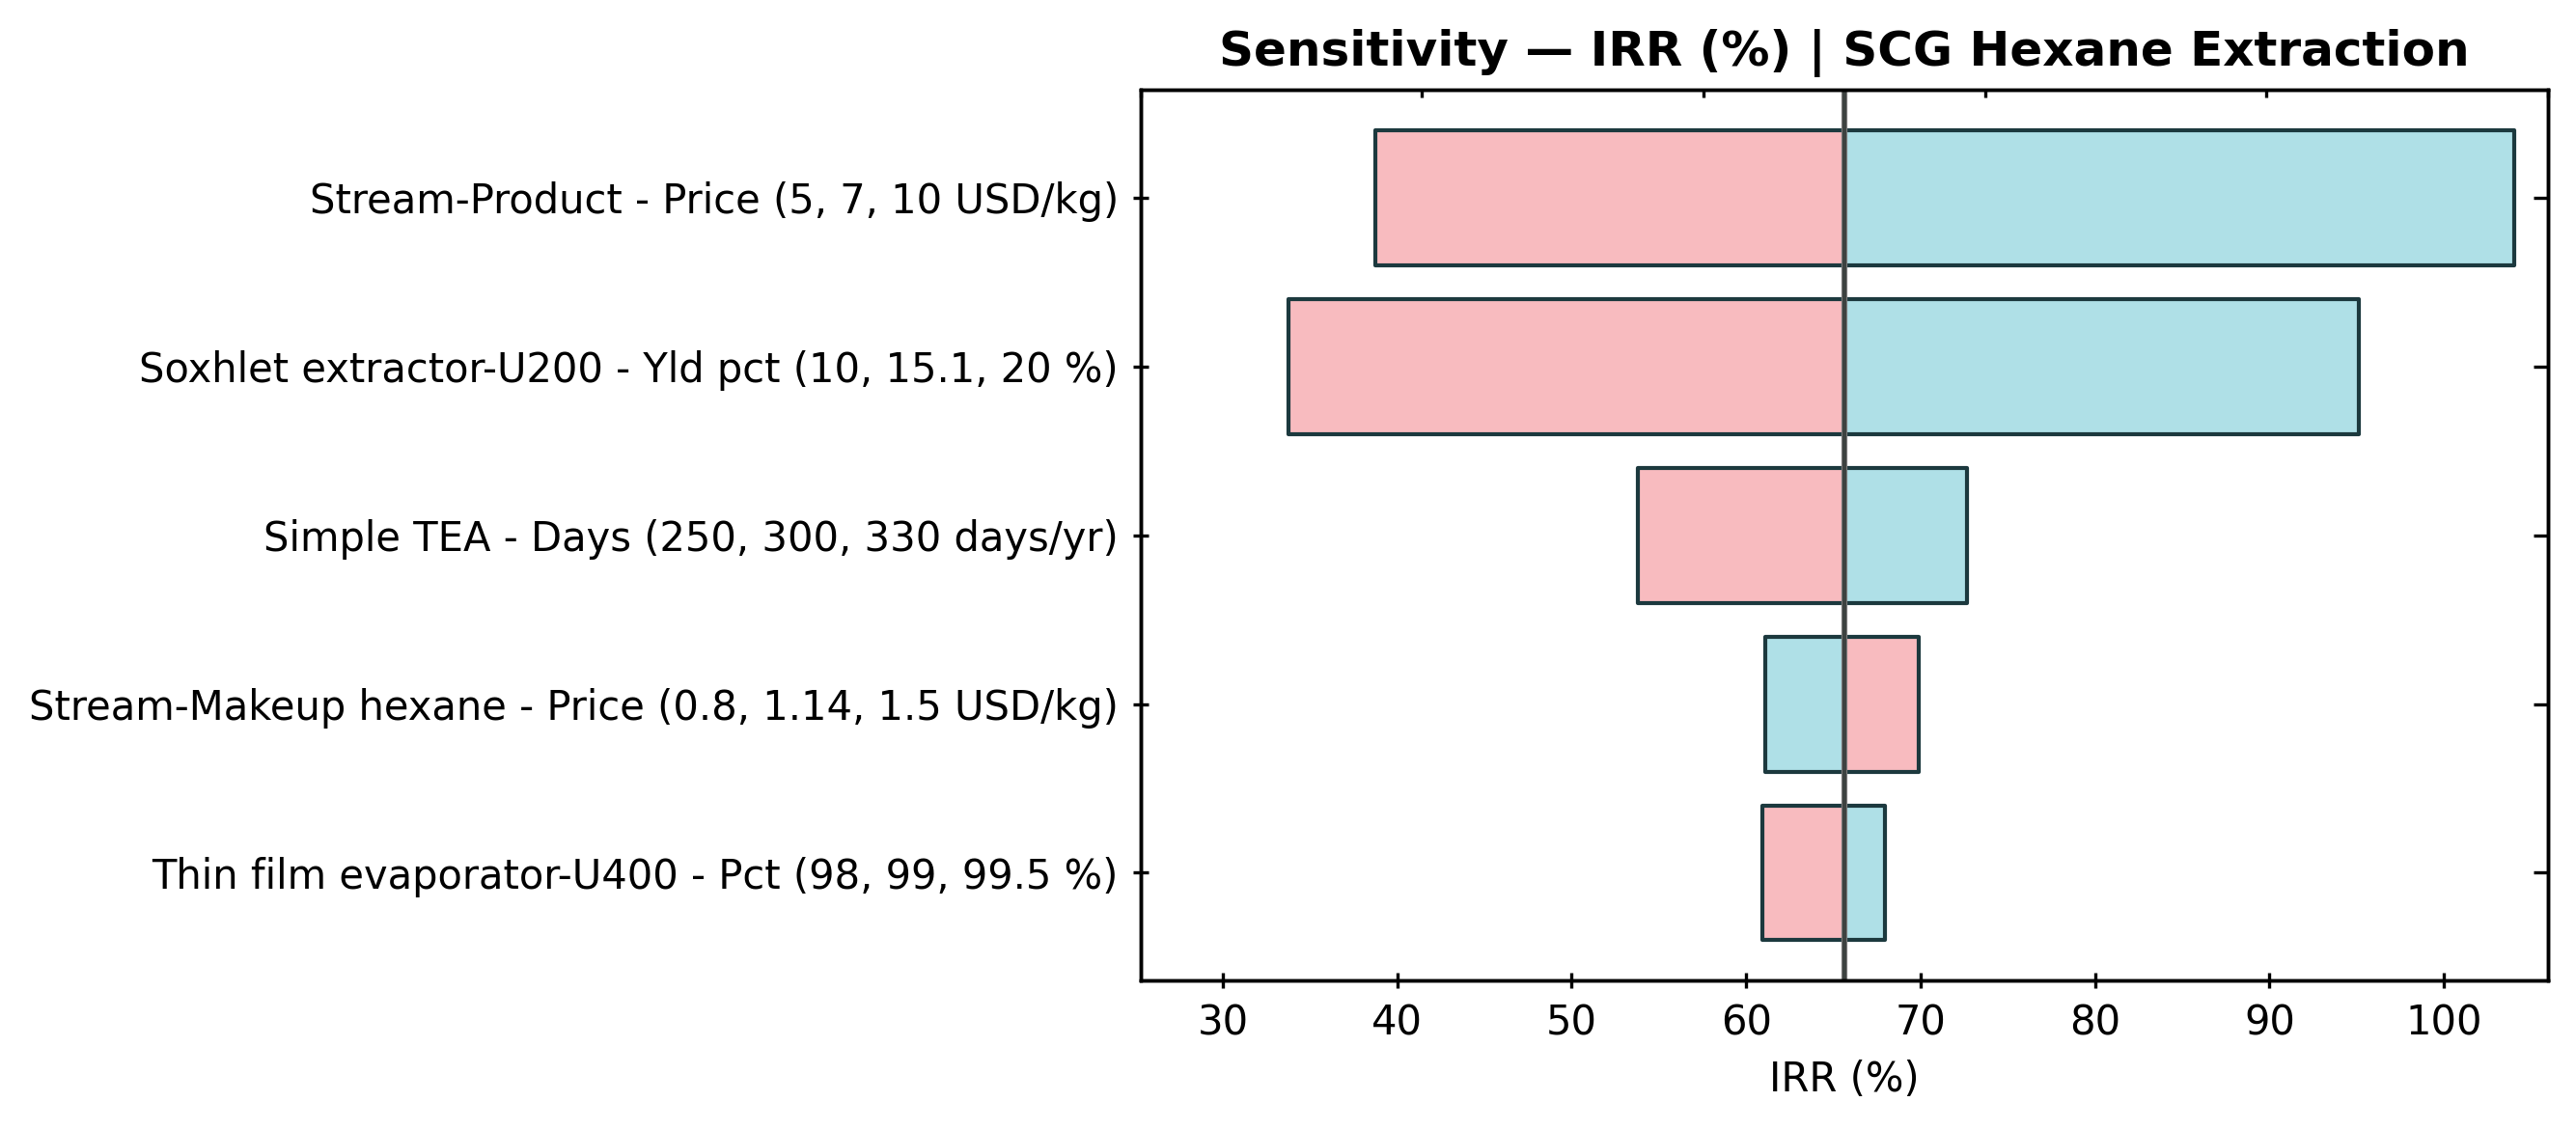


  ✅ Saved → SCG_Hex_Sensitivity_v1.png


In [94]:
try:
    model = bst.Model(sys)

    # ── 1. Extraction yield (coupled: changes propagate through mass balance) ──
    @model.parameter(element=U200, units='%', baseline=YIELD_FRAC * 100,
                     bounds=(10, 20), kind='coupled')
    def set_yield(yld_pct):
        U200.yield_frac = yld_pct / 100.0

    # ── 2. Hexane removal in U400 (coupled) ───────────────────────────────────
    @model.parameter(element=U400, units='%', baseline=0.99 * 100,
                     bounds=(98, 99.5), kind='coupled')
    def set_hexane_removal(pct):
        U400.hexane_removal = pct / 100.0

    # ── 3. Product selling price (isolated: affects economics only) ─────────
    # Call update_product_price(selling_price=price) to cache the new price
    # so that metrics consistently use it instead of reverting to PRODUCT_PRICE
    @model.parameter(element=product_stream, units='USD/kg', baseline=PRODUCT_PRICE,
                     bounds=(5.0, 10.0), kind='isolated')
    def set_product_price(price):
        update_product_price(selling_price=price)

    # ── 4. Hexane price (isolated) ────────────────────────────────────────────
    @model.parameter(element=makeup_hexane, units='USD/kg', baseline=HEXANE_PRICE,
                     bounds=(0.80, 1.50), kind='isolated')
    def set_hexane_price(price):
        makeup_hexane.price = price

    # ── 5. Operating days (isolated: scales annual throughput and revenue) ──────
    @model.parameter(element=tea, units='days/yr', baseline=OP_DAYS,
                     bounds=(250, 330), kind='isolated')
    def set_op_days(days):
        tea.operating_days = days

    # ── Metrics ───────────────────────────────────────────────────────────────
    @model.metric(units='%')
    def IRR_metric():
        # re-sync to _current_selling_price (may have been updated by set_product_price)
        update_product_price()
        try:
            return tea.solve_IRR() * 100
        except Exception:
            return np.nan

    @model.metric(units='M USD')
    def NPV_metric():
        update_product_price()
        tea.IRR = 0.10
        return tea.NPV / 1e6

    @model.metric(units='USD/kg')
    def MPSP_metric():
        update_product_price()
        raw  = tea.solve_price(product_stream)
        frac = product_stream.imass['CoffeeExtract'] / product_stream.F_mass
        update_product_price()   # restore CoffeeExtract-only pricing after solve_price
        return raw / frac

    # ── Run sensitivity ───────────────────────────────────────────────────────
    baseline_s, lower_s, upper_s = model.single_point_sensitivity()

    metrics_list = [IRR_metric, NPV_metric, MPSP_metric]
    param_names  = [p.name for p in model.parameters]

    print(f'\n{"="*62}')
    print(f'  Single-Point Sensitivity Analysis  (5 parameters)')
    print(f'{"="*62}')
    for i_m, m in enumerate(metrics_list):
        b_val = float(baseline_s.iloc[i_m])
        unit  = m.units
        print(f'\n  {m.name} [{unit}]  baseline = {b_val:.3g}')
        for i_p, p_name in enumerate(param_names):
            l_val = float(lower_s.iloc[i_p, i_m])
            u_val = float(upper_s.iloc[i_p, i_m])
            swing = abs(u_val - l_val)
            print(f'    {p_name:<30}: [{l_val:>9.3g}  …  {u_val:>9.3g}]  swing={swing:.3g}')

    # ── Tornado chart ─────────────────────────────────────────────────────────
    p_index = [p.describe(distribution=False) for p in model.parameters]
    irr_idx = IRR_metric.index

    fig, ax = plt.subplots(figsize=(9, 4))
    bst.plots.plot_single_point_sensitivity(
        baseline_s[irr_idx],
        lower_s[irr_idx],
        upper_s[irr_idx],
        name='IRR (%)',
        index=p_index,
        ax=ax,
    )
    ax.set_title('Sensitivity — IRR (%) | SCG Hexane Extraction', fontweight='bold')
    plt.tight_layout()
    plt.savefig('SCG_Hex_Sensitivity_v1.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('\n  ✅ Saved → SCG_Hex_Sensitivity_v1.png')

    # restore
    update_product_price(selling_price=PRODUCT_PRICE)
    tea.operating_days = OP_DAYS

except Exception as e:
    import traceback; traceback.print_exc()
    print(f'  Sensitivity skipped: {e}')


## 8. Monte Carlo uncertainty analysis
Sample extraction yield, product price, and hexane price from uniform distributions (N = 200, Latin Hypercube) and report the probability distributions of IRR and NPV.


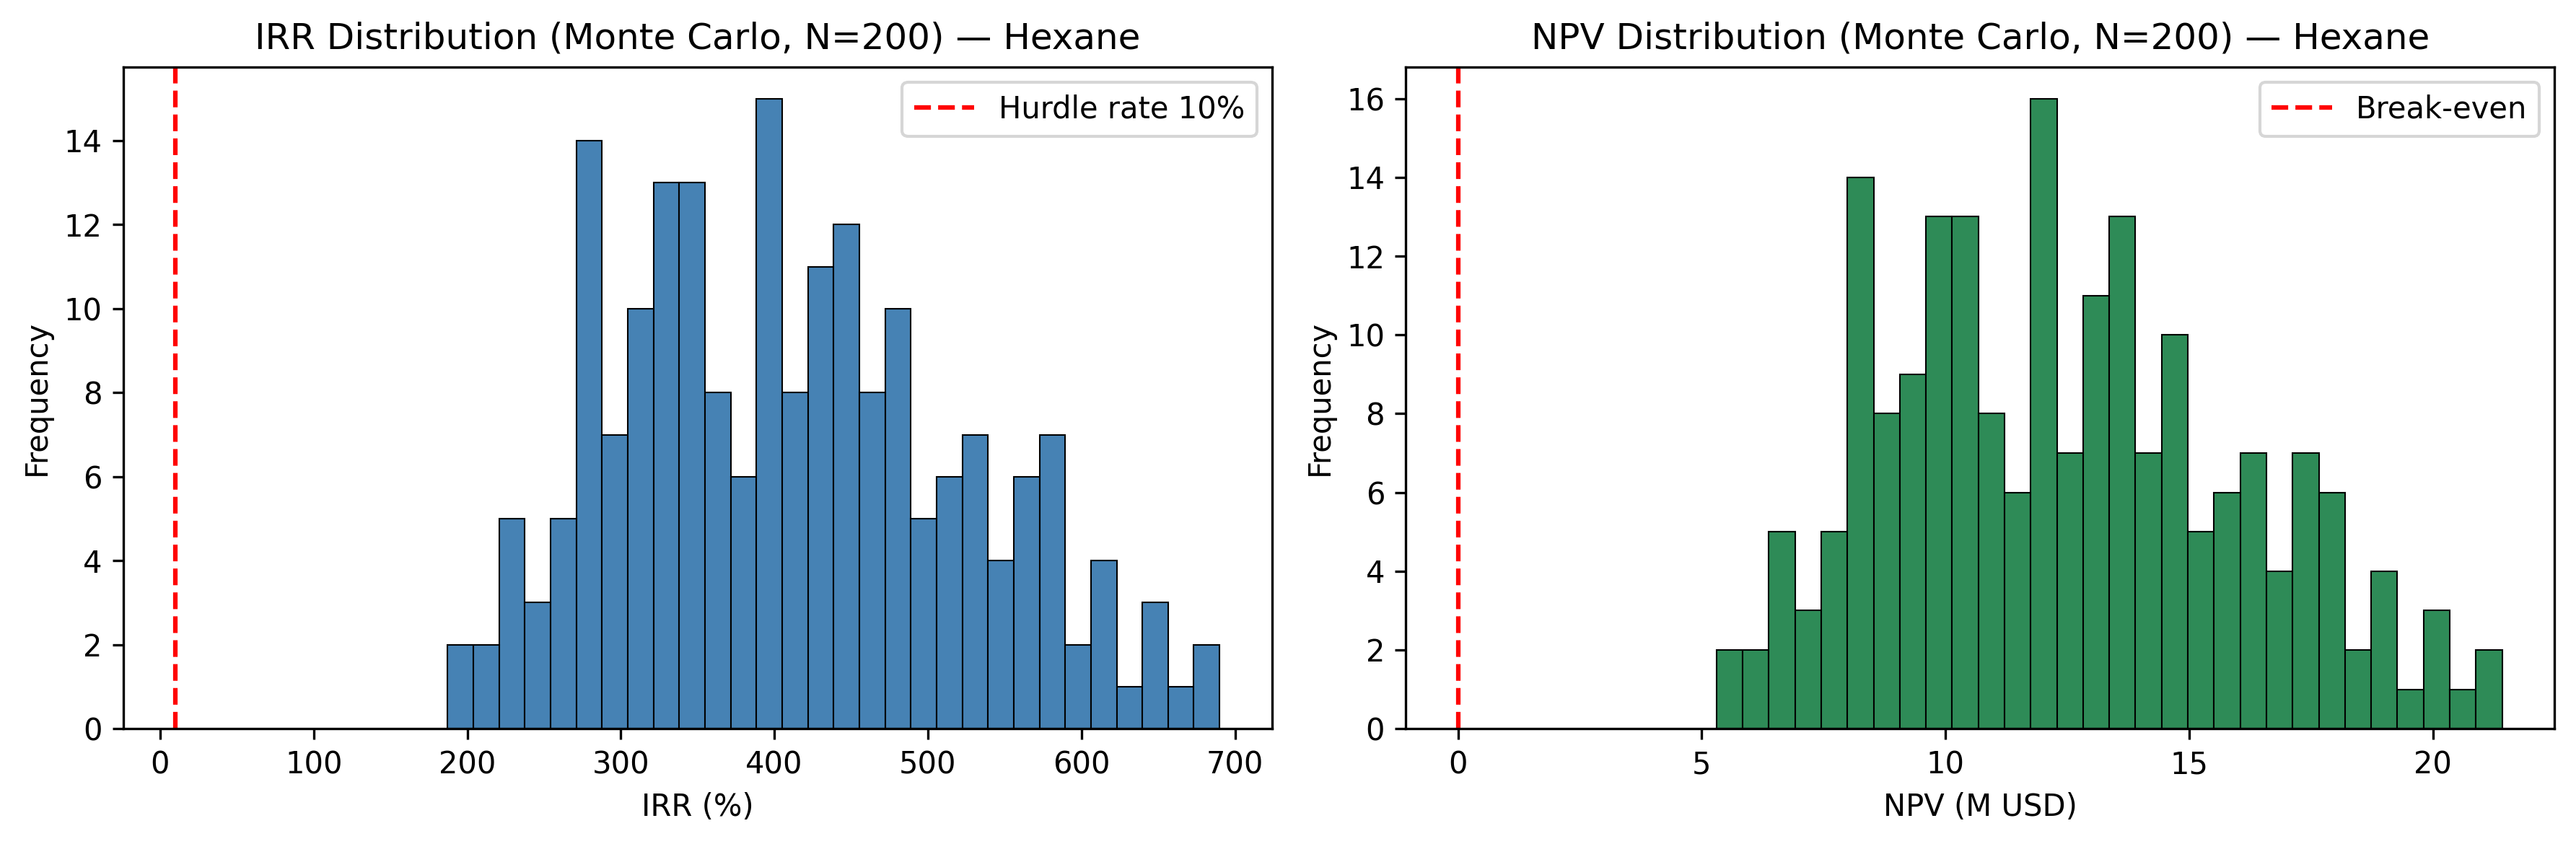

  P(NPV > 0)       : 100.0%
  P(IRR > 10%)     : 100.0%
  Mean IRR         : 410.4%  (std 111.9%)
  Mean NPV         : 12.438 M USD
  ✅ Figure saved → SCG_Hex_MonteCarlo.png


In [90]:
from chaospy import distributions as shape

try:
    mc_model = bst.Model(sys)

    @mc_model.parameter(element=U200, distribution=shape.Uniform(0.10, 0.20),
                         units='frac', kind='coupled')
    def mc_yield(yld):
        U200.yield_frac = yld

    @mc_model.parameter(element=product_stream, distribution=shape.Uniform(15, 35),
                         units='USD/kg', kind='isolated')
    def mc_price(p):
        product_stream.price = p

    @mc_model.parameter(element=makeup_hexane, distribution=shape.Uniform(0.80, 1.50),
                         units='USD/kg', kind='isolated')
    def mc_hexane_price(p):
        makeup_hexane.price = p

    @mc_model.metric(units='%')
    def mc_IRR():
        try:   return tea.solve_IRR() * 100
        except: return np.nan

    @mc_model.metric(units='USD')
    def mc_NPV():
        tea.IRR = 0.10
        return tea.NPV

    np.random.seed(42)
    samples = mc_model.sample(N=200, rule='L')
    mc_model.load_samples(samples)
    mc_model.evaluate()

    tbl = mc_model.table
    irr_col = tbl.iloc[:, -2]
    npv_col = tbl.iloc[:, -1]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    irr_clean = irr_col.dropna()
    npv_clean = npv_col.dropna()

    axes[0].hist(irr_clean, bins=30, color='steelblue', edgecolor='k', linewidth=0.5)
    axes[0].axvline(10, color='red', linestyle='--', label='Hurdle rate 10%')
    axes[0].set_xlabel('IRR (%)'); axes[0].set_ylabel('Frequency')
    axes[0].set_title('IRR Distribution (Monte Carlo, N=200) — Hexane')
    axes[0].legend()

    axes[1].hist(npv_clean / 1e6, bins=30, color='seagreen', edgecolor='k', linewidth=0.5)
    axes[1].axvline(0, color='red', linestyle='--', label='Break-even')
    axes[1].set_xlabel('NPV (M USD)'); axes[1].set_ylabel('Frequency')
    axes[1].set_title('NPV Distribution (Monte Carlo, N=200) — Hexane')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('SCG_Hex_MonteCarlo.png', dpi=200, bbox_inches='tight')
    plt.show()

    p_positive_npv = (npv_clean > 0).mean() * 100
    p_above_hurdle = (irr_clean > 10).mean() * 100
    print(f'  P(NPV > 0)       : {p_positive_npv:.1f}%')
    print(f'  P(IRR > 10%)     : {p_above_hurdle:.1f}%')
    print(f'  Mean IRR         : {irr_clean.mean():.1f}%  (std {irr_clean.std():.1f}%)')
    print(f'  Mean NPV         : {npv_clean.mean() / 1e6:.3f} M USD')
    print('  ✅ Figure saved → SCG_Hex_MonteCarlo.png')

    product_stream.price = PRODUCT_PRICE

except ImportError:
    print('  chaospy not installed — skipping Monte Carlo (pip install chaospy)')
except Exception as e:
    import traceback; traceback.print_exc()
    print(f'  Monte Carlo skipped: {e}')


## 9. Life Cycle Assessment (LCA)
Estimate gate-to-gate environmental impacts per kg CoffeeExtract (coffee oil) using characterization factors for electricity and makeup hexane across four midpoint indicators.


In [91]:
GWP = 'GWP100'; CED = 'CED'; WCP = 'WCP'; HT = 'HT'
INDICATOR_UNITS  = {GWP: 'kg*CO2e', CED: 'MJ', WCP: 'L', HT: 'kg'}
INDICATOR_LABELS = {GWP: 'kg CO₂-eq/kg', CED: 'MJ/kg', WCP: 'L/kg', HT: 'CTUh/kg'}

for key, u in INDICATOR_UNITS.items():
    try:  bst.settings.define_impact_indicator(key=key, units=u)
    except Exception: pass

CF_ELEC   = {GWP: 0.5178, CED: 9.44,  WCP: 2.0,  HT: 4.0e-8}
CF_HEXANE = {GWP: 2.85,   CED: 50.0,  WCP: 2.0,  HT: 1.5e-8}

for key, val in CF_ELEC.items():
    bst.settings.set_electricity_CF(key, val, basis='kWhr', units=INDICATOR_UNITS[key])

for key, val in CF_HEXANE.items():
    makeup_hexane.set_CF(key, val, basis='kg', units=INDICATOR_UNITS[key])

for key in INDICATOR_UNITS:
    scg_feed.set_CF(key, 0.0, basis='kg', units=INDICATOR_UNITS[key])

# ── Use CoffeeExtract flow as functional unit (not total stream mass) ────────
prod_rate = product_stream.imass['CoffeeExtract']   # kg coffee oil / hr
lca_results = {}

print(f'\n{"="*56}')
print(f'  Life Cycle Assessment (LCA) — per kg CoffeeExtract (coffee oil)')
print(f'{"="*56}')

for key in INDICATOR_UNITS:
    try:
        net_rate = sys.get_net_impact(key=key, displace=False)   # impact/hr
        per_kg   = net_rate / prod_rate                          # impact/kg extract
    except Exception as e:
        per_kg = float('nan')
        print(f'  {key}: error — {e}')
    lca_results[key] = per_kg
    print(f'  {key:<8}: {per_kg:.4g}  {INDICATOR_LABELS[key]}')

print(f'{"="*56}')



  Life Cycle Assessment (LCA) — per kg CoffeeExtract (coffee oil)
  GWP100  : 1.627e+04  kg CO₂-eq/kg
  CED     : 2.861e+05  MJ/kg
  WCP     : 1.45e+04  L/kg
  HT      : 0.0001558  CTUh/kg


## 10. Results summary & visualisation
Compile all TEA and LCA results into a 2×3 dashboard figure and a structured summary table, then export to PNG and CSV.


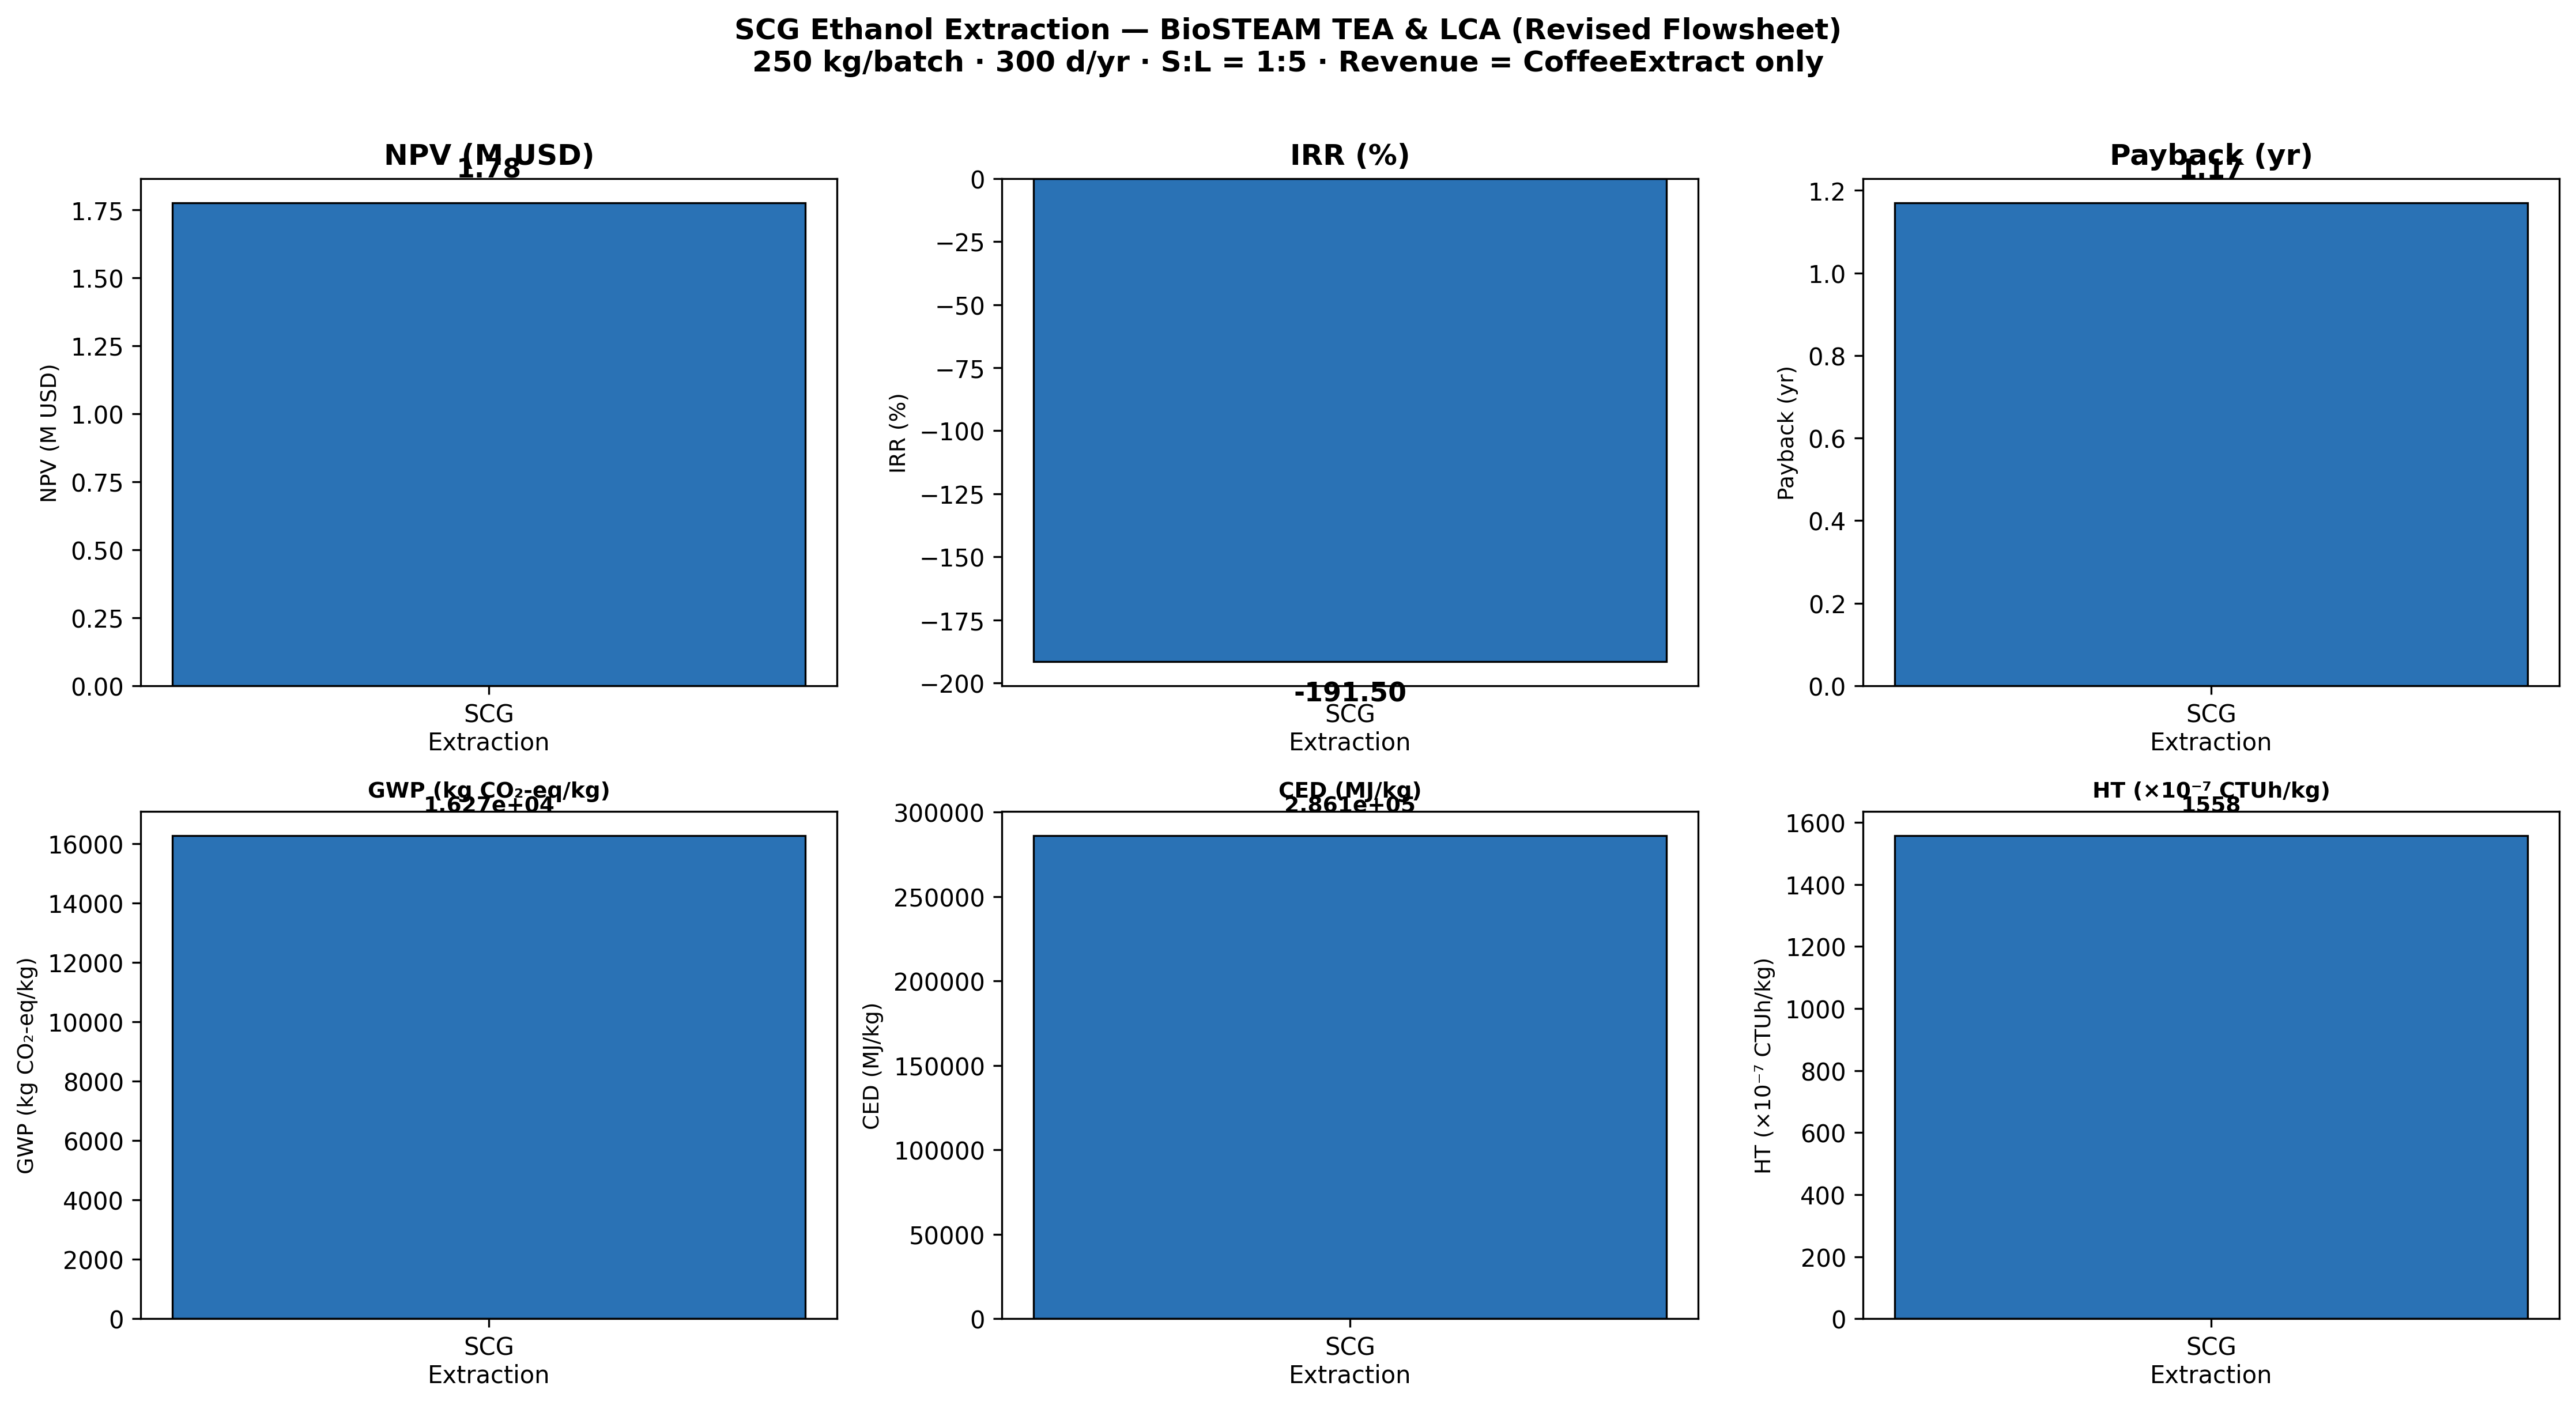

Figure saved → SCG_Hex_Results_v1.png

                           Metric                             Value
── Process ────────────────────── ─────────────────────────────────
        Feed rate (kg/hr wet SCG)                            166.67
       Extract production (kg/hr)                            14.991
            Annual extract (t/yr)                            107.94
              Hexane flow (kg/hr)                            375.00
            Makeup hexane (kg/hr)                            11.175
── TEA ────────────────────────── ─────────────────────────────────
                      TCI (M USD)                             0.469
                      FCI (M USD)                             0.407
             Annual OPEX (USD/yr)                           157,331
          Annual Revenue (USD/yr)                           647,631
              Net income/yr (USD)                           359,641
              NPV — 10 yr (M USD)                             1.777
         

In [92]:
# Re-collect final metrics
update_product_price()   # ← ensure correct pricing before final report
irr       = tea.solve_IRR()
npv       = tea.NPV
annual_NI = tea.net_earnings
dep       = tea.FCI / 10.0
payback   = tea.TCI / (annual_NI + dep) if (annual_NI + dep) > 0 else float('inf')
roi       = annual_NI / tea.TCI if tea.TCI > 0 else 0.0
extract_frac = product_stream.imass['CoffeeExtract'] / product_stream.F_mass
mpsp_raw  = tea.solve_price(product_stream)
mpsp      = mpsp_raw / extract_frac
update_product_price()   # restore

COLOR = '#2A72B5'

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    'SCG Ethanol Extraction — BioSTEAM TEA & LCA (Revised Flowsheet)\n'
    '250 kg/batch · 300 d/yr · S:L = 1:5 · Revenue = CoffeeExtract only',
    fontsize=12, fontweight='bold', y=1.01,
)

tea_items = [
    ('NPV (M USD)',   npv / 1e6),
    ('IRR (%)',       irr * 100),
    ('Payback (yr)',  payback),
]
for col, (ylabel, val) in enumerate(tea_items):
    ax  = axes[0][col]
    bar = ax.bar(['SCG\nExtraction'], [val], color=COLOR,
                 edgecolor='k', linewidth=0.8, width=0.45)
    ax.set_title(ylabel, fontweight='bold')
    ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
    vmax = abs(val) or 1; sign = 1 if val >= 0 else -1
    ax.text(bar[0].get_x() + bar[0].get_width() / 2,
            val + sign * 0.04 * vmax,
            f'{val:.2f}', ha='center',
            va='bottom' if val >= 0 else 'top',
            fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9)

lca_items = [
    (GWP, 'GWP (kg CO₂-eq/kg)', 1.0),
    (CED, 'CED (MJ/kg)',              1.0),
    (HT,  'HT (×10⁻⁷ CTUh/kg)', 1e7),
]
for col, (key, ylabel, scale) in enumerate(lca_items):
    ax  = axes[1][col]
    val = lca_results.get(key, 0) * scale
    ax.bar(['SCG\nExtraction'], [val], color=COLOR, edgecolor='k', linewidth=0.8, width=0.45)
    ax.set_title(ylabel, fontweight='bold', fontsize=9)
    vmax = abs(val) or 1
    ax.text(0, val + 0.04 * vmax, f'{val:.4g}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9)

plt.tight_layout()
plt.savefig('SCG_Hex_Results_v1.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure saved → SCG_Hex_Results_v1.png')

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Metric': [
        '── Process ──────────────────────',
        'Feed rate (kg/hr wet SCG)',
        'Extract production (kg/hr)',
        'Annual extract (t/yr)',
        'Hexane flow (kg/hr)',
        'Makeup hexane (kg/hr)',
        '── TEA ──────────────────────────',
        'TCI (M USD)',
        'FCI (M USD)',
        'Annual OPEX (USD/yr)',
        'Annual Revenue (USD/yr)',
        'Net income/yr (USD)',
        'NPV — 10 yr (M USD)',
        'IRR (%)',
        'Payback (yr)',
        'ROI (%)',
        'MPSP (USD/kg extract)',
        '── LCA (per kg CoffeeExtract) ───',
        'GWP (kg CO2-eq/kg)',
        'CED (MJ/kg)',
        'Water (L/kg)',
        'HT (×10⁻⁷ CTUh/kg)',
    ],
    'Value': [
        '─────────────────────────────────',
        f'{FEED_RATE_WET:.2f}',
        f'{product_stream.imass["CoffeeExtract"]:.3f}',
        f'{product_stream.imass["CoffeeExtract"] * OP_HOURS / 1000:.2f}',
        f'{U600.outs[0].imass["Hexane"]:.2f}',
        f'{makeup_hexane.imass["Hexane"]:.3f}',
        '─────────────────────────────────',
        f'{tea.TCI / 1e6:.3f}',
        f'{tea.FCI / 1e6:.3f}',
        f'{tea.VOC:,.0f}',
        f'{tea.sales:,.0f}',
        f'{annual_NI:,.0f}',
        f'{npv / 1e6:.3f}',
        f'{irr * 100:.1f}',
        f'{payback:.2f}',
        f'{roi * 100:.1f}',
        f'{mpsp:.2f}',
        '─────────────────────────────────',
        f'{lca_results.get(GWP, 0):.4g}',
        f'{lca_results.get(CED, 0):.4g}',
        f'{lca_results.get(WCP, 0):.4g}',
        f'{lca_results.get(HT, 0) * 1e7:.4g}',
    ],
})

print()
print(summary.to_string(index=False))
summary.to_csv('SCG_Hex_Results_v1.csv', index=False)
print('\nResults saved → SCG_Hex_Results_v1.csv')